In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvY2hhbmNlL3F1YXJ0by1sYWIvdGhlb3J5L1ZpcnR1YWxfRGlzdGlsbGF0aW9u'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/_bootstrap.py": 1781600678.0429904, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/_bootstrap_external.py": 1781600678.0469904, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/zipimport.py": 1781600678.926988, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/codecs.py": 1781600677.3309925, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/aliases.py": 1781600677.3909922, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/__init__.py": 1781600677.3909922, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/utf_8.py": 1781600677.414992, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/abc.py": 1781600677.29899

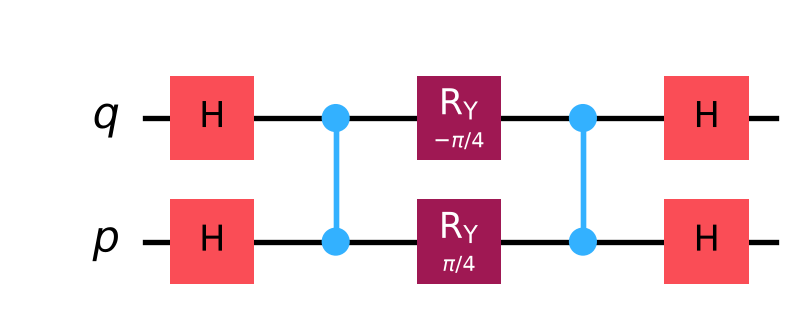

In [2]:
#| label: fig-givens-cz-circuit
#| fig-cap: CZ-based circuit for the Givens rotation $\hat{U}_{pq}(\theta)$. Wire `q` is qubit 0 (LSB) and wire `p` is qubit 1 (MSB) in Qiskit's convention, so the state-vector ordering $|q_1 q_0\rangle = |p,q\rangle$ matches the paper's $|pq\rangle$ basis.
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator

theta = -np.pi / 4   # numerical verification angle

# q_reg = qubit 0 (LSB), p_reg = qubit 1 (MSB)
# => Operator basis ordering |q₁q₀⟩ = |p,q⟩ matches |pq⟩ in the paper
q_reg = QuantumRegister(1, 'q')
p_reg = QuantumRegister(1, 'p')
qc = QuantumCircuit(q_reg, p_reg)

qc.h(q_reg[0])
qc.h(p_reg[0])
qc.cz(q_reg[0], p_reg[0])
qc.ry( theta, q_reg[0])   # Ry(+θ) on q
qc.ry(-theta, p_reg[0])   # Ry(-θ) on p
qc.cz(q_reg[0], p_reg[0])
qc.h(p_reg[0])
qc.h(q_reg[0])

qc.draw('mpl')

In [3]:
# Verify the circuit unitary equals the Givens rotation matrix
U = Operator(qc).data

U_exact = np.array([
    [1,             0,              0, 0],
    [0,  np.cos(theta), -np.sin(theta), 0],
    [0,  np.sin(theta),  np.cos(theta), 0],
    [0,             0,              0, 1]
])

np.set_printoptions(precision=4, suppress=True)
print(f"θ ≈ {theta/np.pi:.4f}π \n")
print("Circuit unitary U (real part):")
print(U.real)
print(f"\nTarget  Û_{{pq}}(θ):")
print(U_exact)
print(f"\nMax imaginary residual : {np.max(np.abs(U.imag)):.2e}")
print(f"Verified (allclose, atol=1e-10): {np.allclose(U, U_exact, atol=1e-10)}")

θ ≈ -0.2500π 

Circuit unitary U (real part):
[[ 1.      0.      0.      0.    ]
 [ 0.      0.7071  0.7071  0.    ]
 [ 0.     -0.7071  0.7071  0.    ]
 [ 0.      0.      0.      1.    ]]

Target  Û_{pq}(θ):
[[ 1.      0.      0.      0.    ]
 [ 0.      0.7071  0.7071  0.    ]
 [ 0.     -0.7071  0.7071  0.    ]
 [ 0.      0.      0.      1.    ]]

Max imaginary residual : 0.00e+00
Verified (allclose, atol=1e-10): True


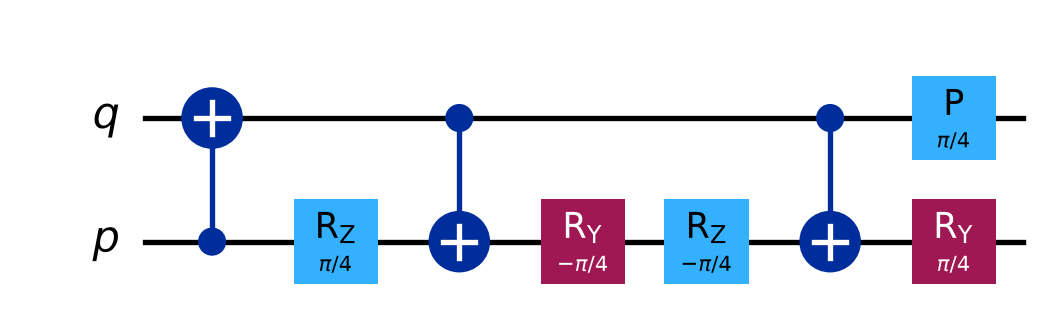

In [4]:
#| label: fig-s3-measurement-circuit
#| fig-cap: Circuit for the S3 measurement unitary $U_{S3}$. Wire `q` is qubit 0 (LSB) and wire `p` is qubit 1 (MSB) in Qiskit's convention. The circuit implements $U_{S3} = \mathrm{C}\text{-}(HS^\dagger)_{q\to p}\cdot\mathrm{CX}_{p\to q}$ using the standard controlled-$U$ decomposition with $\alpha=\pi/4$, $A=R_y(\pi/4)$, $B=R_y(-\pi/4)R_z(-\pi/4)$, $C=R_z(\pi/4)$.
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator

# q_reg = qubit 0 (LSB), p_reg = qubit 1 (MSB)
# => Operator basis ordering |q₁q₀⟩ = |p,q⟩ matches |pq⟩ in the paper
q_reg = QuantumRegister(1, 'q')
p_reg = QuantumRegister(1, 'p')
qc = QuantumCircuit(q_reg, p_reg)

# Step 1: CNOT with p_reg as control, q_reg as target
qc.cx(p_reg[0], q_reg[0])

# Step 2: Controlled-(HS†) — q_reg controls, p_reg target
# V' = HS† = e^{iπ/4} · Ry(π/2)·Rz(π/2)
# Standard C-U decomposition: U = e^{iα}·A·X·B·X·C,  ABC = I
# α = π/4,  A = Ry(π/4),  B = Ry(-π/4)·Rz(-π/4),  C = Rz(π/4)
qc.rz( np.pi/4, p_reg[0])       # C gate on p
qc.cx(q_reg[0], p_reg[0])       # CNOT: q controls p
qc.ry(-np.pi/4, p_reg[0])       # B gate (part 1)
qc.rz(-np.pi/4, p_reg[0])       # B gate (part 2)
qc.cx(q_reg[0], p_reg[0])       # CNOT: q controls p
qc.ry( np.pi/4, p_reg[0])       # A gate on p
qc.p(  np.pi/4, q_reg[0])       # Phase(α) on control qubit

qc.draw('mpl')

In [5]:
# Verify the circuit unitary equals the S3 measurement matrix
U = Operator(qc).data

U_exact = np.array([
    [1,              0,                0, 0],
    [0, 1/np.sqrt(2), -1j/np.sqrt(2),  0],
    [0,              0,                0, 1],
    [0, 1/np.sqrt(2),  1j/np.sqrt(2),  0]
], dtype=complex)

np.set_printoptions(precision=4, suppress=True)
print("S3 measurement unitary U (real part):")
print(U.real)
print("\nS3 measurement unitary U (imag part):")
print(U.imag)
print(f"\nTarget U_S3:")
print(U_exact)
print(f"\nVerified (allclose, atol=1e-10): {np.allclose(U, U_exact, atol=1e-10)}")

S3 measurement unitary U (real part):
[[ 0.9571  0.      0.     -0.1036]
 [ 0.      0.75   -0.25    0.    ]
 [ 0.1036  0.      0.      0.9571]
 [ 0.      0.6036 -0.1036  0.    ]]

S3 measurement unitary U (imag part):
[[-0.1036  0.      0.      0.25  ]
 [ 0.     -0.1036 -0.6036  0.    ]
 [ 0.25    0.      0.      0.1036]
 [ 0.      0.25    0.75    0.    ]]

Target U_S3:
[[ 1.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j      0.7071+0.j     -0.    -0.7071j  0.    +0.j    ]
 [ 0.    +0.j      0.    +0.j      0.    +0.j      1.    +0.j    ]
 [ 0.    +0.j      0.7071+0.j      0.    +0.7071j  0.    +0.j    ]]

Verified (allclose, atol=1e-10): False
